In [24]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML

from tracklab import ExperimentReader
from configurations import apply_general_styles, set_font_sizes, create_fig, FONTSIZES

apply_general_styles()


In [9]:
experiment_name = 'concentration_test'
reader =  ExperimentReader(experiment_name,base_dir='../data')
run_id = reader.list_runs()[-1]
print(f"Loading metrics for run_id: {run_id}")
data = reader.load_metrics(run_id)

Loading metrics for run_id: run_002


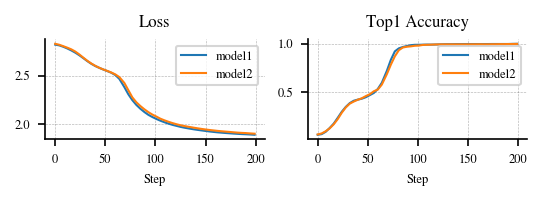

In [10]:
fig , axes = create_fig(ncols=2,h=0.35)
set_font_sizes(conf='tight')
for i , metric in enumerate(['loss','top1_accuracy']):
    ax = axes[i]
    ax.grid(ls='--',c='k',alpha=0.3,lw=0.3)
    for model in ['model1','model2']:
        dat = data[(data['metric'] == metric) & (data['note'] == model)]
        ax.plot(dat['step'],dat['value'],label=model,lw=1)
        ax.set_title(metric.replace('_',' ').title(),size=FONTSIZES['s'])
        ax.set_xlabel('Step',size=FONTSIZES['xs'])
    ax.legend(fontsize=FONTSIZES['xs'])

In [ ]:
list_artifacts = reader.list_artifacts(run_id)
list_artifacts

names_list = [
    ['u_ov2_p','u_ov2_e','u_ov2_ov1_p','u_ov2_ov1_e'],
    ['e_qk2_e','p_qk2_p','e_qk2_ov1_e','p_qk2_ov1_p','e_ov1_qk2_e','p_ov1_qk2_p','e_ov1_qk2_ov1_e','p_ov1_qk2_ov1_p'],
    ['e_qk1_e','p_qk1_p']
]

for list in names_list:
    print('')
    for name in list:
        M = reader.load_artifact(run_id,name+'.npy')
        print(f'{name} shape: {M.shape}')



u_ov2_p shape: (50, 16, 32)
u_ov2_e shape: (50, 16, 16)
u_ov2_ov1_p shape: (50, 16, 32)
u_ov2_ov1_e shape: (50, 16, 16)

e_qk2_e shape: (50, 16, 16)
p_qk2_p shape: (50, 32, 32)
e_qk2_ov1_e shape: (50, 16, 16)
p_qk2_ov1_p shape: (50, 32, 32)
e_ov1_qk2_e shape: (50, 16, 16)
p_ov1_qk2_p shape: (50, 32, 32)
e_ov1_qk2_ov1_e shape: (50, 16, 16)
p_ov1_qk2_ov1_p shape: (50, 32, 32)

e_qk1_e shape: (50, 16, 16)
p_qk1_p shape: (50, 32, 32)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML

names_list = [
    ['u_ov2_p','u_ov2_e','u_ov2_ov1_p','u_ov2_ov1_e'],
    ['e_qk2_e','p_qk2_p','e_qk2_ov1_e','p_qk2_ov1_p','e_ov1_qk2_e','p_ov1_qk2_p','e_ov1_qk2_ov1_e','p_ov1_qk2_ov1_p'],
    ['e_qk1_e','p_qk1_p']
]

# ── Load all matrices ──────────────────────────────────────────────────────────
data = []
for name_row in names_list:
    row_data = []
    for name in name_row:
        M = reader.load_artifact(run_id, name + '.npy')
        row_data.append(M)
    data.append(row_data)

n_rows = len(names_list)
n_cols = max(len(row) for row in names_list)   # 8 (widest row)
T = data[0][0].shape[0]                         # number of time steps

# ── Pre-compute colour limits per matrix (stable across time) ──────────────────
vmins, vmaxs = [], []
for row_data in data:
    row_vmins, row_vmaxs = [], []
    for M in row_data:
        row_vmins.append(M.min())
        row_vmaxs.append(M.max())
    vmins.append(row_vmins)
    vmaxs.append(row_vmaxs)

# ── Build figure ───────────────────────────────────────────────────────────────
fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(2.2 * n_cols, 2.5 * n_rows),
    constrained_layout=True
)
# Make axes always 2-D
if n_rows == 1:
    axes = axes[np.newaxis, :]
if n_cols == 1:
    axes = axes[:, np.newaxis]

# Hide all axes first; we'll re-enable only the used ones
for ax in axes.flat:
    ax.set_visible(False)

# Create imshow objects and titles
ims = []
for r, (name_row, row_data) in enumerate(zip(names_list, data)):
    row_ims = []
    for c, (name, M) in enumerate(zip(name_row, row_data)):
        ax = axes[r, c]
        ax.set_visible(True)
        im = ax.imshow(
            M[0],
            aspect='auto',
            interpolation='nearest',
            vmin=vmins[r][c],
            vmax=vmaxs[r][c],
            cmap='RdBu_r'
        )
        ax.set_title(name, fontsize=13, pad=3)
        ax.tick_params(labelsize=6)
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        row_ims.append(im)
    ims.append(row_ims)

title = fig.suptitle('t = 0', fontsize=11, y=1.01)

# ── Animation update function ──────────────────────────────────────────────────
def update(t):
    for r, row_data in enumerate(data):
        for c, M in enumerate(row_data):
            ims[r][c].set_data(M[t])
    title.set_text(f't = {t}')
    return [im for row_ims in ims for im in row_ims] + [title]

anim = animation.FuncAnimation(
    fig, update,
    frames=T,
    interval=100,   # ms between frames – adjust as needed
    blit=True
)

# ── Display inline and optionally save ────────────────────────────────────────
HTML(anim.to_jshtml())   # interactive scrubber inside the notebook

# Logit evolution

In [16]:
experiment_name = 'concentration_test'
reader =  ExperimentReader(experiment_name,base_dir='../data')
cfg = reader.load_config(run_id)
run_id = reader.list_runs()[-1]
print(f"Loading metrics for run_id: {run_id}")
data = reader.load_metrics(run_id)

Loading metrics for run_id: run_002


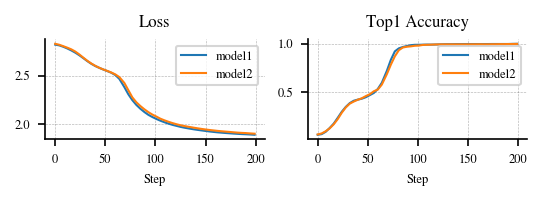

In [12]:
fig , axes = create_fig(ncols=2,h=0.35)
set_font_sizes(conf='tight')
for i , metric in enumerate(['loss','top1_accuracy']):
    ax = axes[i]
    ax.grid(ls='--',c='k',alpha=0.3,lw=0.3)
    for model in ['model1','model2']:
        dat = data[(data['metric'] == metric) & (data['note'] == model)]
        ax.plot(dat['step'],dat['value'],label=model,lw=1)
        ax.set_title(metric.replace('_',' ').title(),size=FONTSIZES['s'])
        ax.set_xlabel('Step',size=FONTSIZES['xs'])
    ax.legend(fontsize=FONTSIZES['xs'])

In [74]:
list_logits = ['model1_logits','model2_logits']

print("Model Parameters:")
for param in ['d_model','vocab_size','seq_len','rank']:
    print(f"{param}: {cfg['model_args'][param]}")

print("")

logits_data = {}
for name in list_logits:
    M = reader.load_artifact(run_id,name+'.npy')
    logits_data[name] = M
    print(f'{name} shape: {M.shape}')

print(f"There are {M.shape[0]} steps and {M.shape[1]} samples in the logits.")


Model Parameters:
d_model: 512
vocab_size: 16
seq_len: 32
rank: 64

model1_logits shape: (50, 15, 32, 16)
model2_logits shape: (50, 15, 32, 16)
There are 50 steps and 15 samples in the logits.


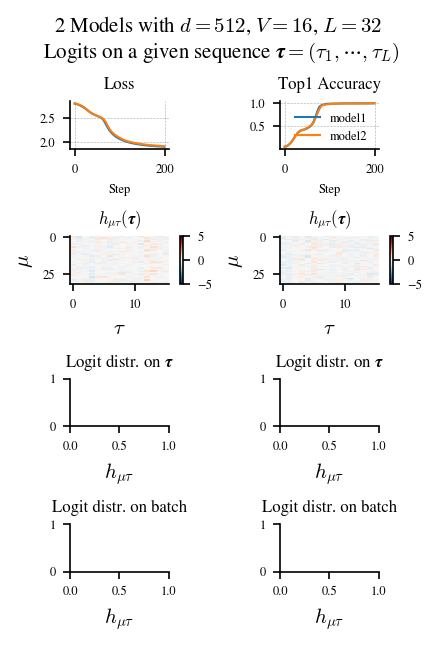

In [ ]:
set_font_sizes(conf='tight')
fig , axes = create_fig(nrows=4,ncols=2,size='single',h=1.2,w=0.8,sharex=False)

# Fixed Plots
fig.suptitle(rf'2 Models with $d={cfg["model_args"]["d_model"]}$, $V={cfg["model_args"]["vocab_size"]}$, $L={cfg["model_args"]["seq_len"]}$ '+
             f'\n'+fr' Logits on a given sequence $ \boldsymbol{{\tau}} = (\tau_1,\cdots,\tau_L)$',fontsize=FONTSIZES['m'])
for i , metric in enumerate(['loss','top1_accuracy']):
    ax = axes[0,i]
    ax.grid(ls='--',c='k',alpha=0.3,lw=0.3)
    for model in ['model1','model2']:
        dat = data[(data['metric'] == metric) & (data['note'] == model)]
        ax.plot(dat['step'],dat['value'],label=model,lw=1)
        ax.set_title(metric.replace('_',' ').title(),size=FONTSIZES['s'])
        ax.set_xlabel('Step',size=FONTSIZES['xs'])
    if i==1: ax.legend(fontsize=FONTSIZES['xs'],frameon=False)

for ax in axes[1,:]:
    ax.set_xlabel(r'$\tau$')
    ax.set_ylabel(r'$\mu$')
    ax.set_title(r'$h_{\mu\tau}(\boldsymbol{\tau})$',size=FONTSIZES['s'])

for ax in axes[2,:]:
    ax.set_xlabel(r'$h_{\mu\tau}$')
    ax.set_title(rf'Logit distr. on $\boldsymbol{{\tau}}$',size=FONTSIZES['s'])

for ax in axes[3,:]:
    ax.set_xlabel(r'$h_{\mu\tau}$')
    ax.set_title(rf'Logit distr. on batch',size=FONTSIZES['s'])

# Parameters
lim = 5
i_batch = 0
bins = 10

# Collect artists
ims = {}
bars_sample = {}

# Init
for i, (name,M) in enumerate(logits_data.items()):
    ax = axes[1,i]
    ims[i] = ax.imshow(M[0, i_batch], aspect='auto', interpolation='nearest',
                        vmin=-lim, vmax=lim, cmap='RdBu_r')
    plt.colorbar(ims[c], ax=ax, fraction=0.046, pad=0.04)

    ax = axes[2,i]
  

In [ ]:
set_font_sizes(conf='tight')
fig, axes = create_fig(nrows=4, ncols=2, size='single', h=1.4, w=1, sharex=False)

# ── Suptitle ───────────────────────────────────────────────────────────────────
fig.suptitle(
    rf'2 Models with $d={cfg["model_args"]["d_model"]}$, $V={cfg["model_args"]["vocab_size"]}$, $L={cfg["model_args"]["seq_len"]}$'
    f'\n' + rf'Logits on a given sequence $\boldsymbol{{\tau}} = (\tau_1,\cdots,\tau_L)$',
    fontsize=FONTSIZES['m']
)

# ── Parameters ─────────────────────────────────────────────────────────────────
lim     = 4
i_batch = 0
n_bins  = 30
bins    = np.linspace(-lim, lim, n_bins)

# ── Fixed labels & titles ──────────────────────────────────────────────────────
for i, metric in enumerate(['loss', 'top1_accuracy']):
    ax = axes[0, i]
    ax.grid(ls='--', c='k', alpha=0.3, lw=0.3)
    for model in ['model1', 'model2']:
        dat = data[(data['metric'] == metric) & (data['note'] == model)]
        ax.plot(dat['step'], dat['value'], label=model, lw=1)
    ax.set_title(metric.replace('_', ' ').title(), size=FONTSIZES['s'])
    ax.set_xlabel('Step', size=FONTSIZES['xs'])
    if i == 1:
        ax.legend(fontsize=FONTSIZES['xs'], frameon=False)

for ax in axes[1, :]:
    ax.set_xlabel(r'$\tau$', size=FONTSIZES['xs'])
    ax.set_ylabel(r'$\mu$', size=FONTSIZES['xs'])
    ax.set_title(r'$h_{\mu\tau}(\boldsymbol{\tau})$', size=FONTSIZES['s'])

for ax in axes[2, :]:
    ax.set_xlabel(r'$h_{\mu\tau}$', size=FONTSIZES['xs'])
    ax.set_title(rf'Logit distr. on $\boldsymbol{{\tau}}$', size=FONTSIZES['s'])

for ax in axes[3, :]:
    ax.set_xlabel(r'$h_{\mu\tau}$', size=FONTSIZES['xs'])
    ax.set_title(rf'Logit distr. on batch', size=FONTSIZES['s'])

# ── Pre-compute stable y-limits for histograms ─────────────────────────────────
def max_hist_count(arrays, bins):
    return max(np.histogram(a.ravel(), bins=bins)[0].max() for a in arrays) * 1.15

ylim_sample = {i: max_hist_count([M[t, i_batch] for t in range(T)], bins)
               for i, M in enumerate(logits_data.values())}
ylim_batch  = {i: max_hist_count([M[t]          for t in range(T)], bins)
               for i, M in enumerate(logits_data.values())}

# ── Helper: initialise a bar chart, return bar container ──────────────────────
def init_bars(ax, vals, bins, color, ylim):
    counts, _ = np.histogram(vals.ravel(), bins=bins)
    bars = ax.bar(bins[:-1], counts, width=np.diff(bins), align='edge',
                  color=color, alpha=0.85, edgecolor='none')
    ax.set_xlim(bins[0], bins[-1])
    ax.set_ylim(0, ylim)
    ax.tick_params(labelsize=6)
    return bars

def update_bars(bars, vals, bins):
    counts, _ = np.histogram(vals.ravel(), bins=bins)
    for bar, h in zip(bars, counts):
        bar.set_height(h)

# ── Collect mutable artists ────────────────────────────────────────────────────
ims          = {}
bars_sample  = {}
bars_batch   = {}
vlines       = {}

steps = data[data['metric'] == 'loss']['step'].unique()
T     = len(steps)

for i, (name, M) in enumerate(logits_data.items()):

    # row 0 — vlines on learning curves
    vlines[i] = axes[0, i].axvline(steps[0], color='r', lw=0.8, ls='--', alpha=0.8)

    # row 1 — logit matrix
    ims[i] = axes[1, i].imshow(
        M[0, i_batch], aspect='auto', interpolation='nearest',
        vmin=-lim, vmax=lim, cmap='RdBu_r'
    )
    plt.colorbar(ims[i], ax=axes[1, i], fraction=0.046, pad=0.04)

    # row 2 — histogram over single sequence
    bars_sample[i] = init_bars(axes[2, i], M[0, i_batch], bins,
                                color='steelblue', ylim=ylim_sample[i])

    # row 3 — histogram over full batch
    bars_batch[i]  = init_bars(axes[3, i], M[0], bins,
                                color='coral',     ylim=ylim_batch[i])

step_label = fig.text(0.5, 0.98, f'Step {steps[0]}', ha='center',
                      fontsize=FONTSIZES['xs'], color='r')

# ── Update ─────────────────────────────────────────────────────────────────────
def update(t):
    step = steps[t]
    step_label.set_text(f'Step {step}')

    for i, M in enumerate(logits_data.values()):
        vlines[i].set_xdata([step])
        ims[i].set_data(M[t, i_batch])
        update_bars(bars_sample[i], M[t, i_batch], bins)
        update_bars(bars_batch[i],  M[t],          bins)

    return [step_label, *vlines.values(), *ims.values(),
            *bars_sample.values(), *bars_batch.values()]

anim = animation.FuncAnimation(fig, update, frames=T, interval=150, blit=False)

html_str = anim.to_jshtml()
with open('logits_animation.html', 'w') as f:
    f.write(html_str)

HTML(html_str)